# 直接从 Event Data 还原触球热图

本 notebook 不进行分箱，也不构建离散热图矩阵。它直接使用 JSON 中每次有效触球的原始 `(x, y)` 坐标估计二维核密度，并生成与参考图片相同尺寸的透明 PNG。

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
from PIL import Image


## 1. 文件与参数

In [2]:
MATCH_JSON = Path(
    r'D:\code\project (Optimal Transport)\Data Extractor and Processor'
    r'\England_Premier_League\england-premier-league-2015-2016-arsenal-aston-villa.json'
)
ARSENAL_REFERENCE = Path(r'D:\code\Project\arsenal.png')
ASTON_REFERENCE = Path(r'D:\code\Project\aston.png')
OUTPUT_DIR = Path.cwd() / 'Event_KDE_Reconstructed'

IMAGE_SIZE = (112, 72)       # width, height
BW_ADJUST = 0.50             # KDE 带宽；保留更细的热点结构
DENSITY_THRESHOLD = 0.08     # 小于球队峰值 8% 的区域透明
EDGE_SOFTNESS = 0.015        # 透明轮廓的羽化宽度
ALPHA = 0.50                 # 与参考图一致的整体透明度
COLOR_LEVELS = 100           # 颜色层级
ROTATE_AWAY_180 = True       # 客队坐标旋转 180°，统一进攻方向

assert MATCH_JSON.exists(), f'找不到比赛文件：{MATCH_JSON}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. 直接从 events 提取主客队触球坐标

只保留 `isTouch=True`，并且同时具有 `playerId`、`x`、`y` 的事件。球队归属通过主客队球员名单确定。

In [3]:
def load_match(json_path):
    with Path(json_path).open('r', encoding='utf-8') as file:
        return json.load(file)


def get_event_type(event):
    event_type = event.get('type')
    if isinstance(event_type, dict):
        return event_type.get('displayName') or event_type.get('name')
    return event_type


def extract_touch_events(match, side, rotate_away_180=True):
    player_ids = {
        player.get('playerId')
        for player in match[side]['players']
        if player.get('playerId') is not None
    }

    records = []
    for event in match['events']:
        player_id = event.get('playerId')
        x = event.get('x')
        y = event.get('y')

        if not event.get('isTouch', False):
            continue
        if player_id not in player_ids or x is None or y is None:
            continue

        x = float(x)
        y = float(y)
        if not (0 <= x <= 100 and 0 <= y <= 100):
            continue

        rotate = side == 'away' and rotate_away_180
        plot_x = 100.0 - x if rotate else x
        plot_y = 100.0 - y if rotate else y
        records.append({
            'playerId': player_id,
            'x': x,
            'y': y,
            'plot_x': plot_x,
            'plot_y': plot_y,
            'minute': event.get('minute'),
            'second': event.get('second'),
            'eventType': get_event_type(event),
        })

    return pd.DataFrame(records)


match = load_match(MATCH_JSON)
home_events = extract_touch_events(match, 'home', ROTATE_AWAY_180)
away_events = extract_touch_events(match, 'away', ROTATE_AWAY_180)

print(f"{match['home']['name']}：{len(home_events)} 个触球坐标")
print(f"{match['away']['name']}：{len(away_events)} 个触球坐标")
display(home_events.head())

Arsenal：774 个触球坐标
Aston Villa：591 个触球坐标


,playerId,x,y,plot_x,plot_y,minute,second,eventType
0,24444,50.0,50.1,50.0,50.1,0,1,Pass
1,13756,50.9,49.9,50.9,49.9,0,2,Pass
2,69738,40.2,50.3,40.2,50.3,0,3,Pass
3,13756,54.5,54.5,54.5,54.5,0,4,Pass
4,125211,37.3,28.0,37.3,28.0,0,8,Pass


## 3. 用原始事件坐标计算连续二维 KDE

`gaussian_kde` 直接接收所有事件坐标。密度乘以事件数量后表示触球强度；主客队使用同一颜色上限，以保留两队触球总量的差异。

In [4]:
def estimate_event_density(events, image_size=(364, 238), bw_adjust=0.50):
    if len(events) < 3:
        raise ValueError('至少需要 3 个有效触球事件')

    width, height = image_size
    x_coordinates = np.linspace(0, 100, width)
    y_coordinates = np.linspace(0, 100, height)
    grid_x, grid_y = np.meshgrid(x_coordinates, y_coordinates)

    event_coordinates = np.vstack([
        events['plot_x'].to_numpy(),
        events['plot_y'].to_numpy(),
    ])
    kde = gaussian_kde(event_coordinates)
    kde.set_bandwidth(kde.factor * bw_adjust)

    evaluation_coordinates = np.vstack([grid_x.ravel(), grid_y.ravel()])
    density = kde(evaluation_coordinates).reshape(height, width)

    # gaussian_kde 默认积分为 1；乘以事件数后得到事件强度。
    return density * len(events)


home_density = estimate_event_density(home_events, IMAGE_SIZE, BW_ADJUST)
away_density = estimate_event_density(away_events, IMAGE_SIZE, BW_ADJUST)
shared_maximum = max(home_density.max(), away_density.max())

print('Arsenal KDE peak:', home_density.max())
print('Aston Villa KDE peak:', away_density.max())
print('Aston / Arsenal peak ratio:', away_density.max() / home_density.max())

Arsenal KDE peak: 0.2129369155531163
Aston Villa KDE peak: 0.14756736194501668
Aston / Arsenal peak ratio: 0.6930097656467958


## 4. 将连续密度直接转换成透明 PNG

In [5]:
BRIGHT_JET = LinearSegmentedColormap.from_list(
    'bright_jet',
    plt.cm.jet(np.linspace(0.12, 0.90, 256)),
)


def density_to_rgba(
    density,
    shared_maximum,
    threshold=0.08,
    edge_softness=0.015,
    alpha=0.50,
    color_levels=100,
):
    # 两队使用同一颜色归一化范围。
    normalized = np.clip(density / shared_maximum, 0, 1)
    if color_levels is not None and color_levels > 1:
        normalized = np.floor(normalized * (color_levels - 1)) / (color_levels - 1)

    rgba = BRIGHT_JET(normalized)

    # 每队按自身峰值确定外轮廓，并对轮廓边缘进行羽化。
    cutoff = density.max() * threshold
    softness = max(density.max() * edge_softness, np.finfo(float).eps)
    opacity_mask = np.clip((density - cutoff) / softness, 0, 1)
    rgba[..., 3] = opacity_mask * alpha

    # 数组第一行对应 y=0；PNG 第一行是图像顶部，所以需要上下翻转。
    rgba = np.flipud(rgba)
    rgba_uint8 = np.round(rgba * 255).astype(np.uint8)
    rgba_uint8[rgba_uint8[..., 3] == 0, :3] = 0
    return rgba_uint8


def save_density_png(density, shared_maximum, output_path):
    rgba = density_to_rgba(
        density,
        shared_maximum,
        threshold=DENSITY_THRESHOLD,
        edge_softness=EDGE_SOFTNESS,
        alpha=ALPHA,
        color_levels=COLOR_LEVELS,
    )
    image = Image.fromarray(rgba, mode='RGBA')
    image.save(output_path)
    return image


arsenal_output = OUTPUT_DIR / 'arsenal_from_events.png'
aston_output = OUTPUT_DIR / 'aston_from_events.png'

arsenal_image = save_density_png(home_density, shared_maximum, arsenal_output)
aston_image = save_density_png(away_density, shared_maximum, aston_output)

print(arsenal_output.resolve())
print(aston_output.resolve())

D:\code\project (Optimal Transport)\Data Extractor and Processor\Event_KDE_Reconstructed\arsenal_from_events.png
D:\code\project (Optimal Transport)\Data Extractor and Processor\Event_KDE_Reconstructed\aston_from_events.png


## 5. 参考图与 event data 还原图对比

## 调整还原效果

- 热点太模糊：减小 `BW_ADJUST`。
- 热点过于零碎：增大 `BW_ADJUST`。
- 有色区域太大：增大 `DENSITY_THRESHOLD`。
- 不旋转客队方向：设置 `ROTATE_AWAY_180 = False`。

所有颜色都来自原始 event 坐标的 KDE 强度，没有经过空间分箱。

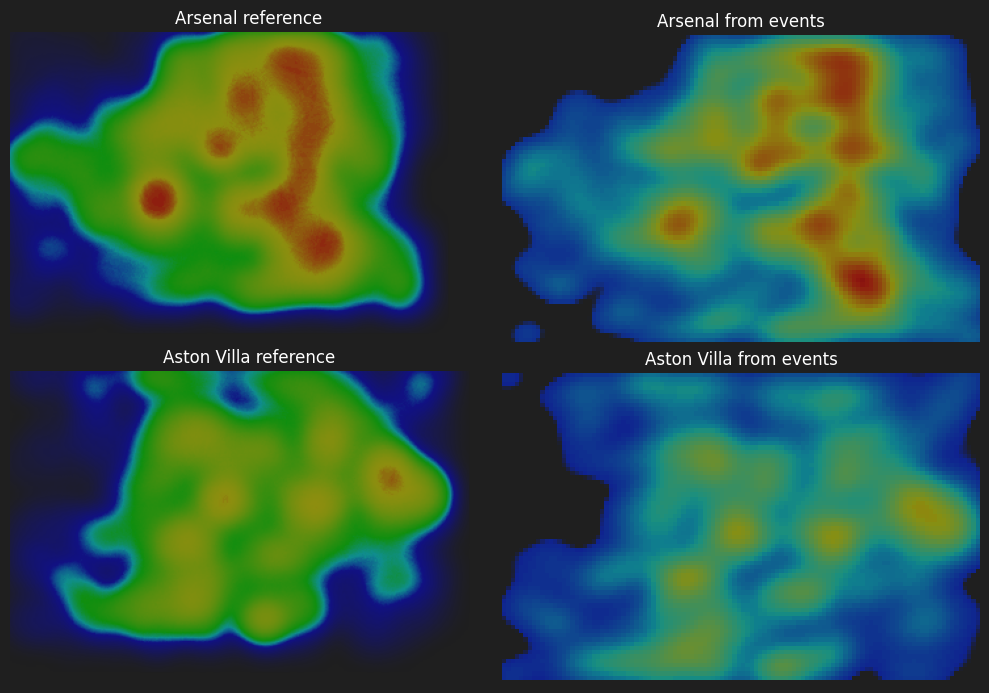

In [6]:
comparison = [
    ('Arsenal reference', ARSENAL_REFERENCE),
    ('Arsenal from events', arsenal_output),
    ('Aston Villa reference', ASTON_REFERENCE),
    ('Aston Villa from events', aston_output),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), facecolor='#1f1f1f')
for ax, (title, image_path) in zip(axes.flat, comparison):
    ax.set_facecolor('#1f1f1f')
    if image_path.exists():
        ax.imshow(Image.open(image_path).convert('RGBA'))
    else:
        ax.text(0.5, 0.5, str(image_path), ha='center', va='center', color='white')
    ax.set_title(title, color='white')
    ax.set_axis_off()
plt.tight_layout()
plt.show()